In [1]:
import pandas as pd
import os
import pyprojroot, sys
from pyprojroot.criterion import has_file
sys.path.insert(0, str(pyprojroot.find_root(has_file("pyproject.toml"))))

from dotenv import load_dotenv,find_dotenv

# load_dotenv()

env_file_path = find_dotenv()
print("当前加载的 .env 文件路径:", env_file_path)
# 2. 加载该文件
load_dotenv(env_file_path, override=True)

当前加载的 .env 文件路径: /workspace/worker/kdwk/Chrono/genuis/mizar/.env


True

In [2]:
tcn_file = "/workspace/worker/kdwk/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/tcn_mse/result/1017042849036245/metrics/test_results.csv"
tf_file = "/workspace/worker/kdwk/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/transformer_mse/result/1008463795875014/metrics/test_results.csv"
htf_file = "/workspace/worker/kdwk/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/hybrid_transformer_mse/result/1092133054981645/metrics/test_results.csv"

In [3]:
results_tcn = pd.read_csv(tcn_file)
results_tf = pd.read_csv(tf_file)
results_htf = pd.read_csv(htf_file)

In [4]:
results_htf.head().columns

Index(['trade_time', 'code', 'evaluation_segment', 'label_valid', 'action_raw',
       'prediction_bound_std', 'predicted_z', 'target_z', 'predicted_ret_h',
       'future_ret_h', 'prediction_error_z', 'squared_error_z', 'ret_scale',
       'direction', 'confidence', 'net_er_out', 'er_value'],
      dtype='object')

In [5]:
results_tf1 = results_tf[['trade_time','code','predicted_z', 'future_ret_h']]
results_tcn1 = results_tcn[['trade_time','code','predicted_z', 'future_ret_h']]
results_htf1 = results_htf[['trade_time','code','predicted_z', 'future_ret_h']]

In [16]:
results_tf1_RB = results_tf1[results_tf1['code']=='RB']
results_tf1_HC = results_tf1[results_tf1['code']=='HC']

In [17]:
results_htf1_RB = results_htf1[results_htf1['code']=='RB']
results_htf1_HC = results_htf1[results_htf1['code']=='HC']

In [18]:
results_tcn1_RB = results_tcn1[results_tcn1['code']=='RB']
results_tcn1_HC = results_tcn1[results_tcn1['code']=='HC']

In [6]:
from lib.cux001 import FactorEvaluate1

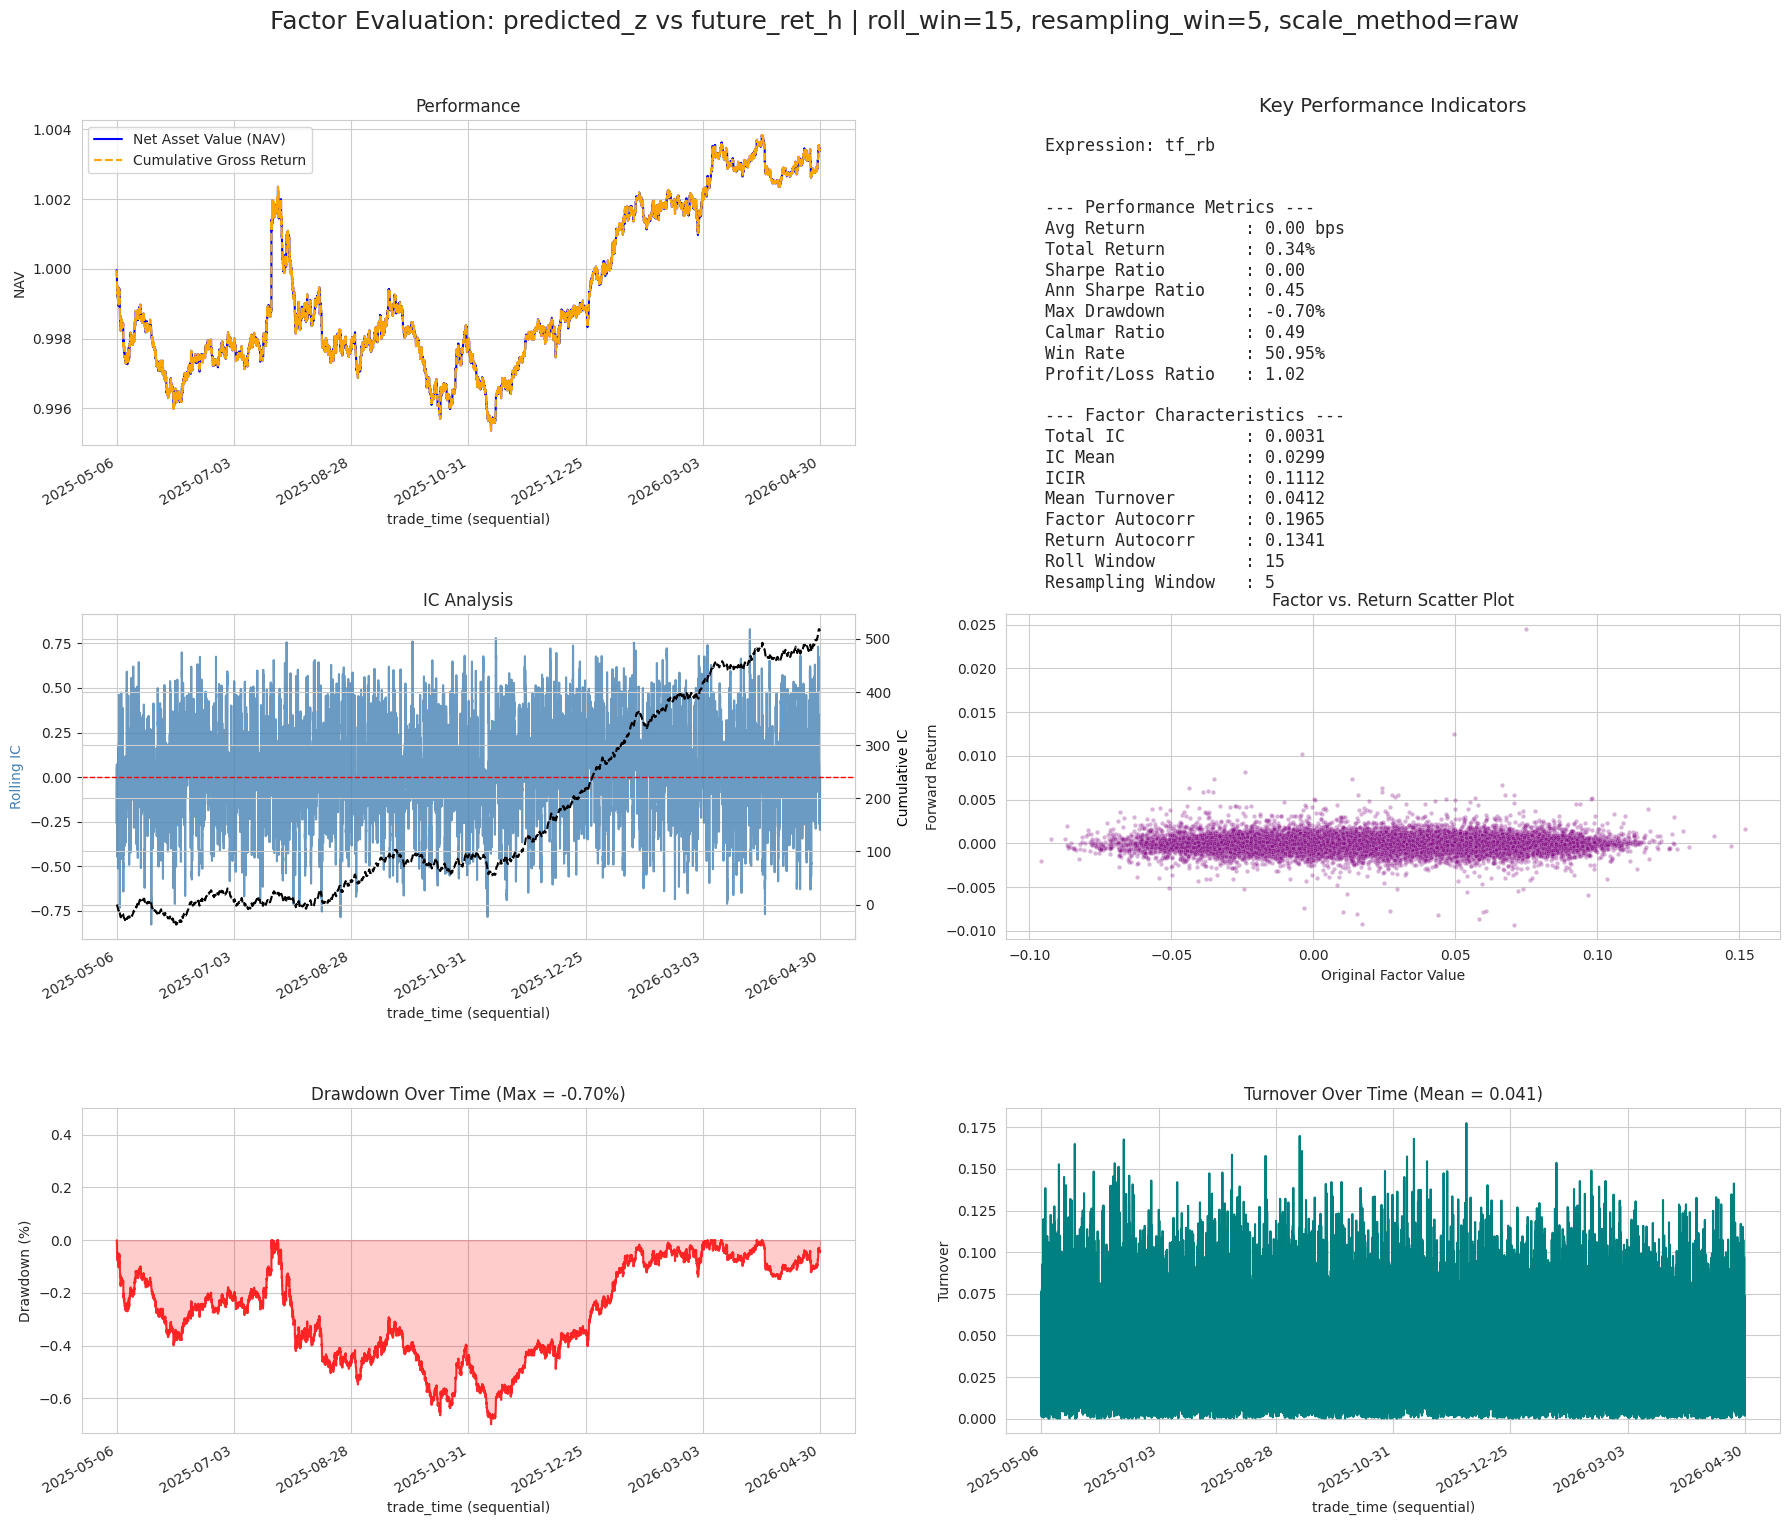

In [21]:
evaluate1_tf_rb = FactorEvaluate1(factor_data=results_tf1_RB,
                                factor_name='predicted_z',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='tf_rb',
                                resampling_win=5)
evaluate1_tf_rb.run()
evaluate1_tf_rb.plot_results()

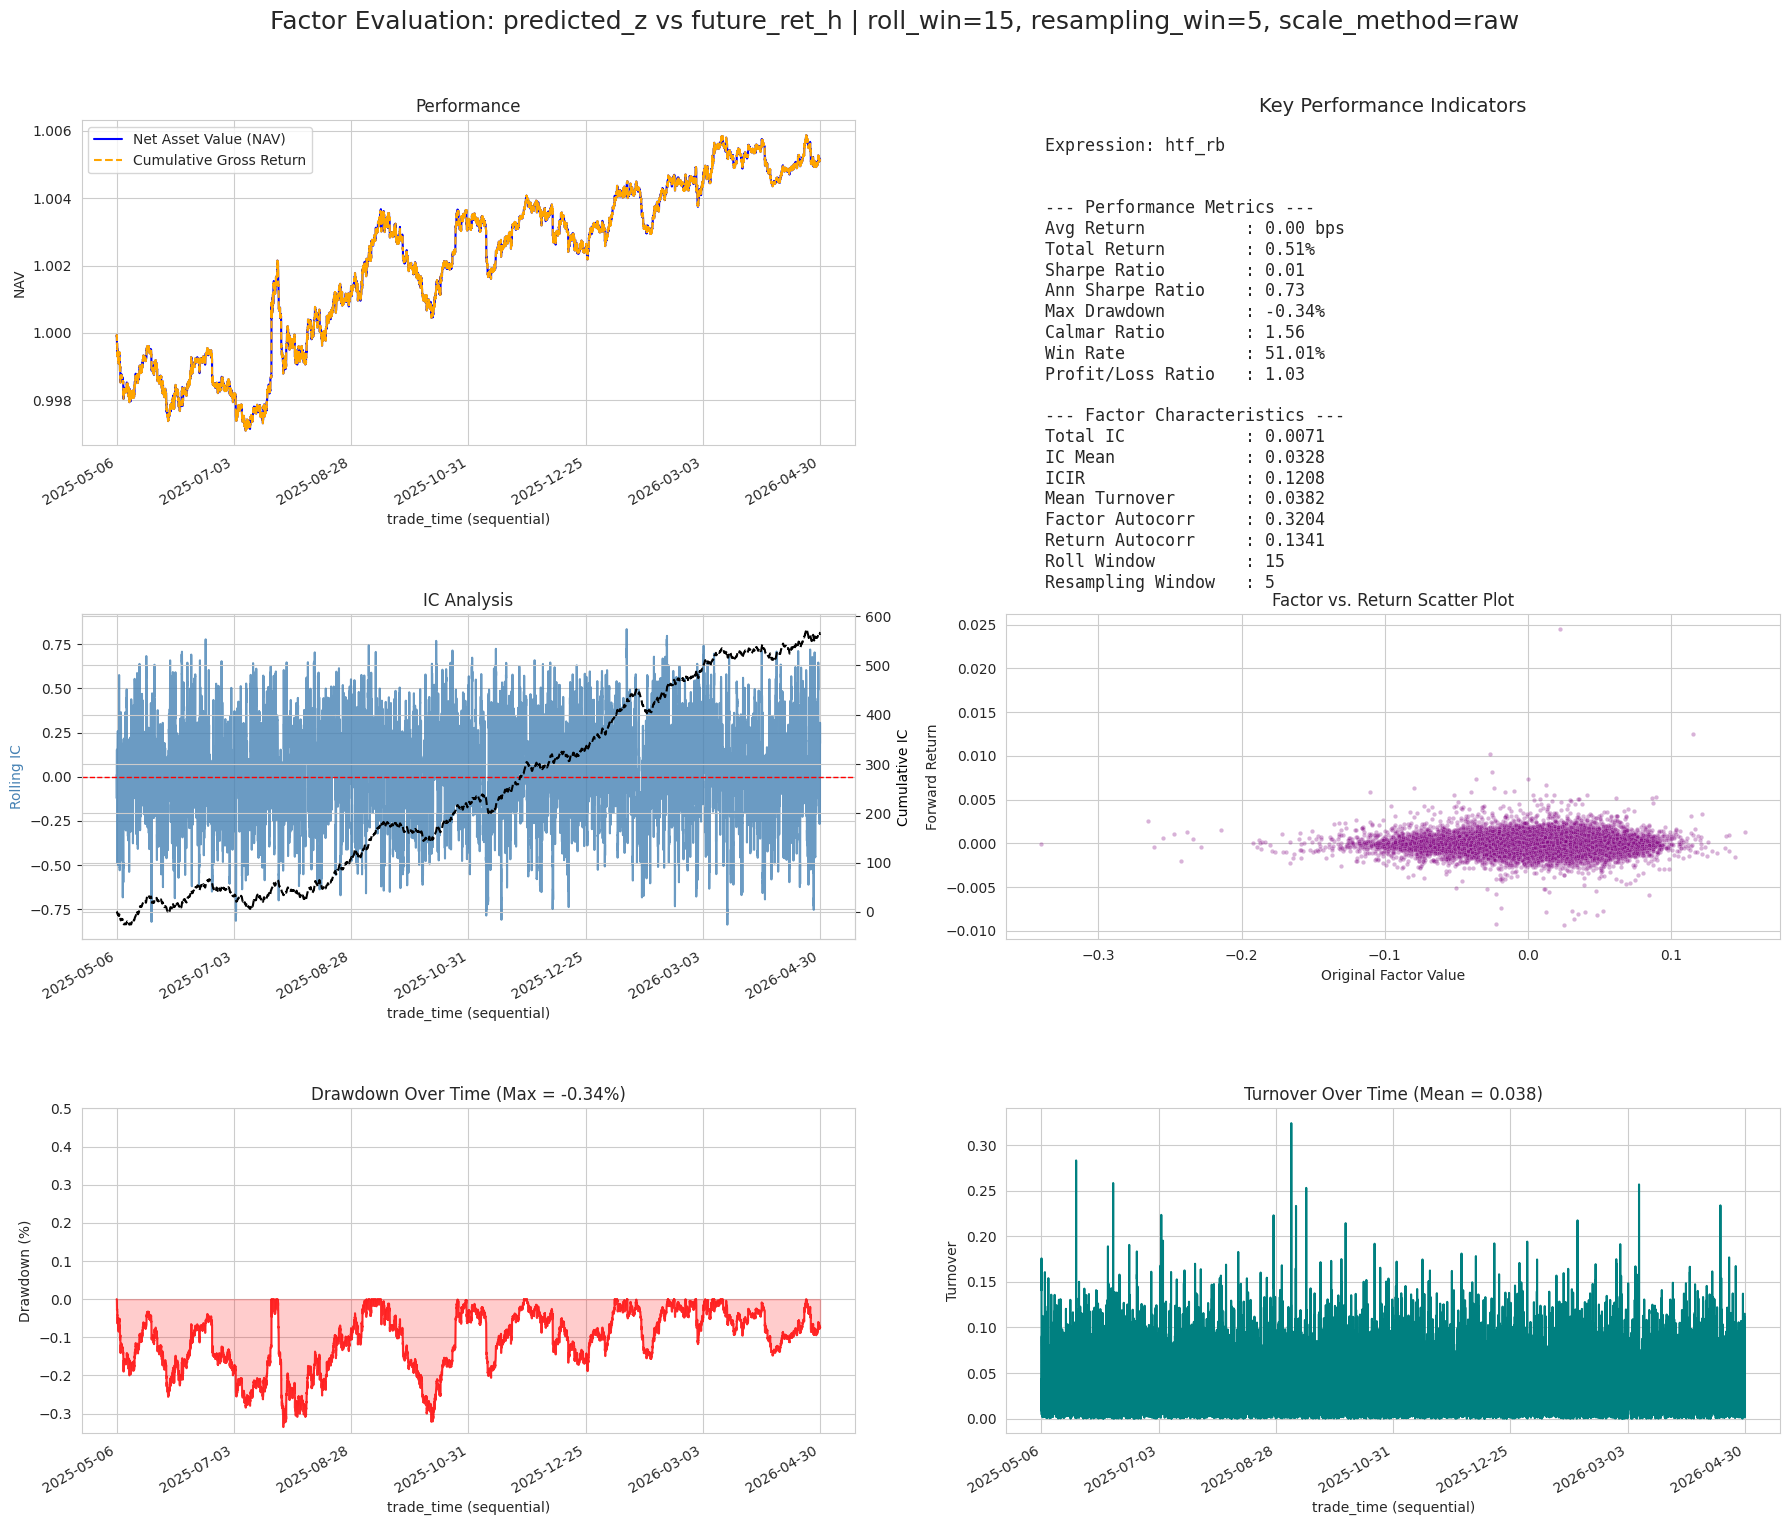

In [22]:
evaluate1_htf_rb = FactorEvaluate1(factor_data=results_htf1_RB,
                                factor_name='predicted_z',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='htf_rb',
                                resampling_win=5)
evaluate1_htf_rb.run()
evaluate1_htf_rb.plot_results()

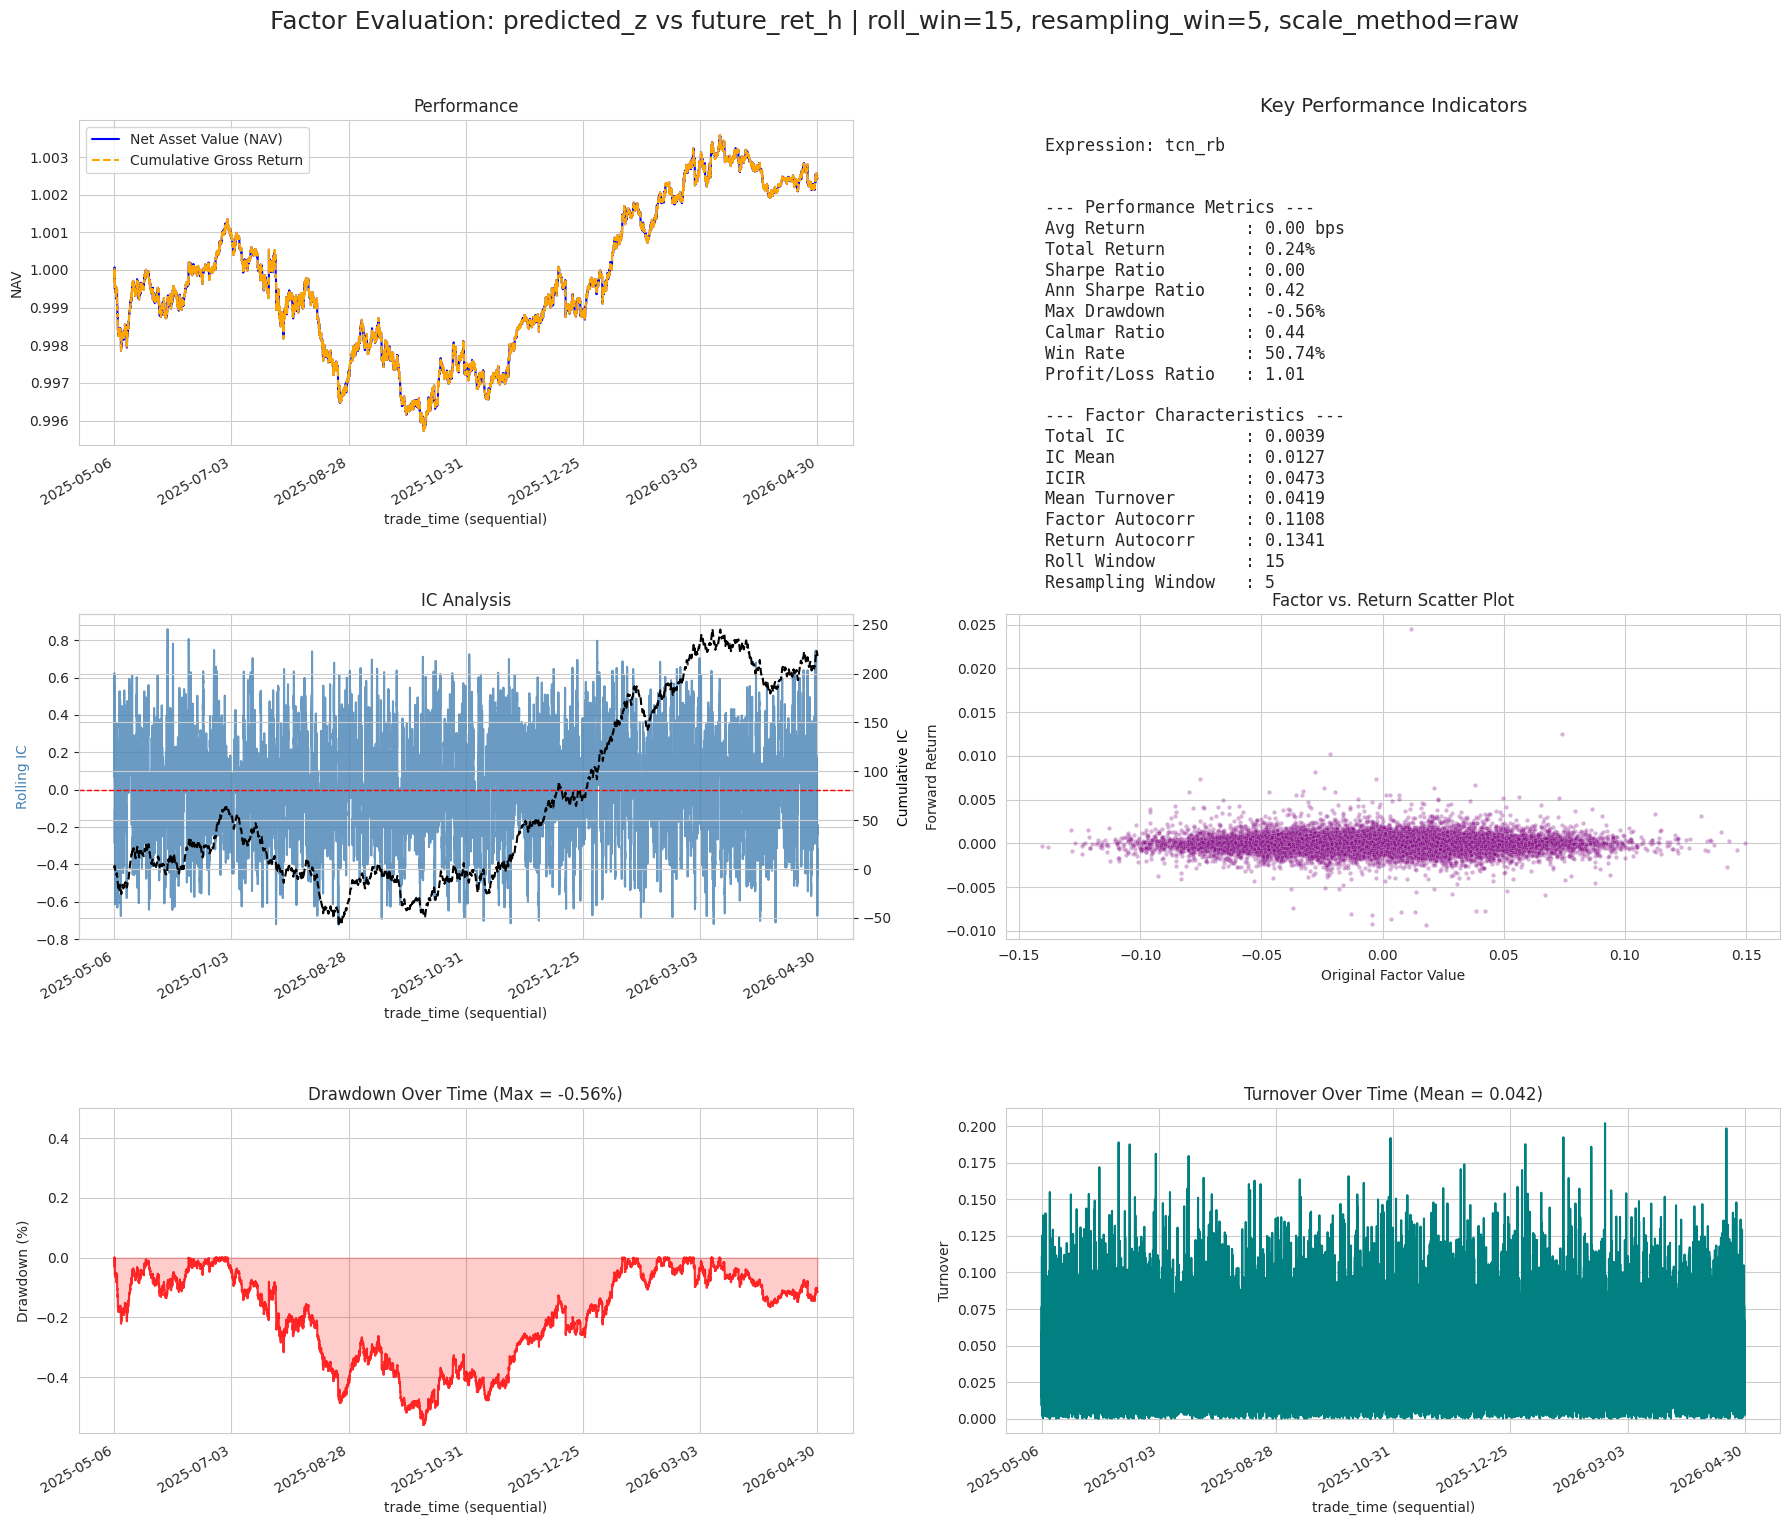

In [23]:
evaluate1_tcn1_rb = FactorEvaluate1(factor_data=results_tcn1_RB,
                                factor_name='predicted_z',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='tcn_rb',
                                resampling_win=5)
evaluate1_tcn1_rb.run()
evaluate1_tcn1_rb.plot_results()

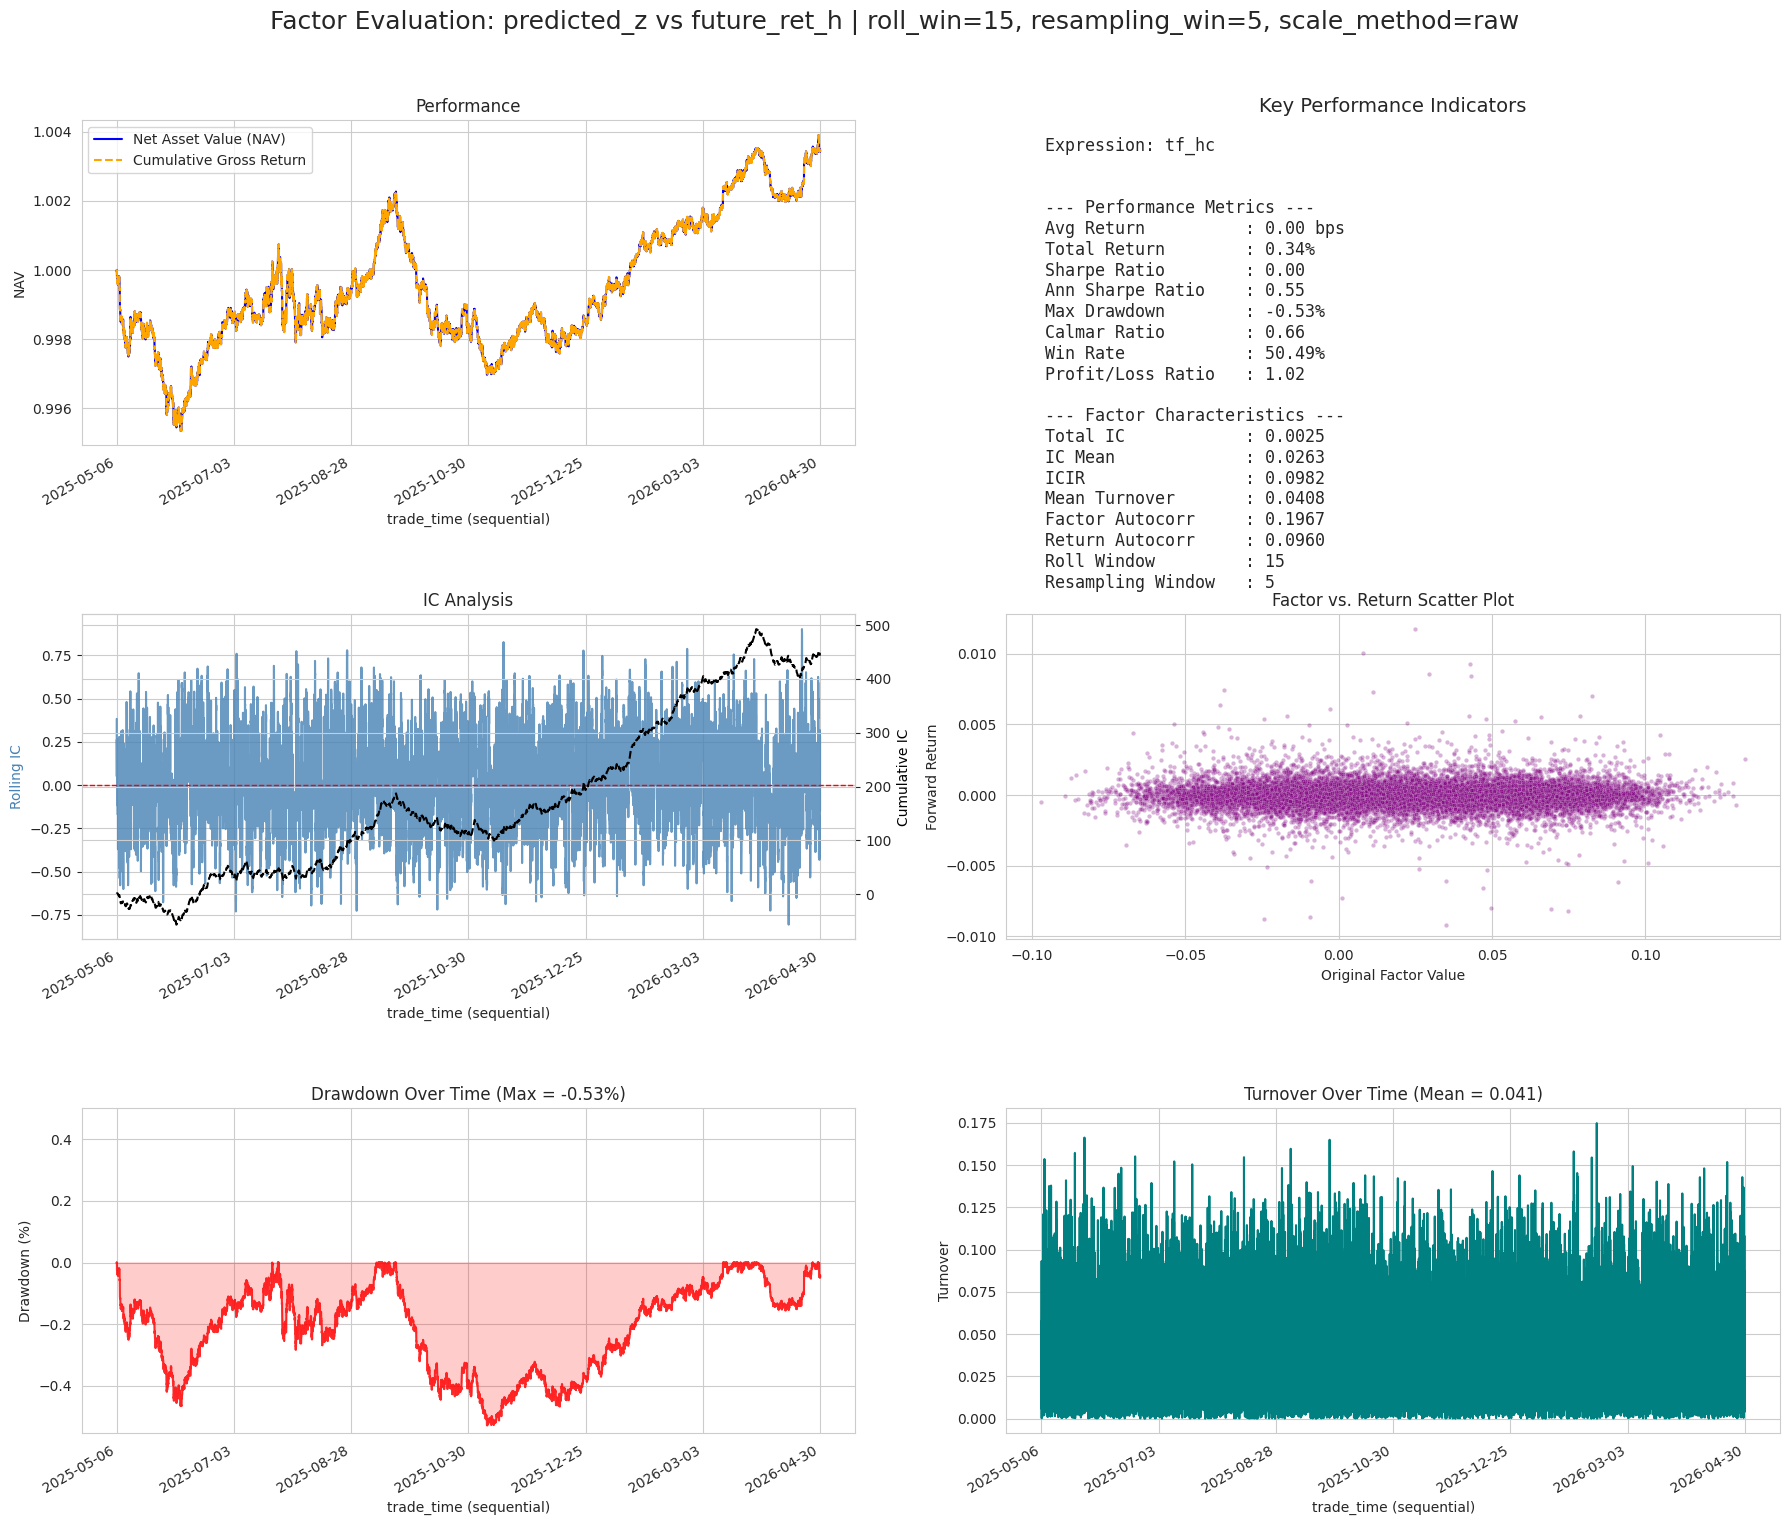

In [24]:
evaluate1_tf_hc = FactorEvaluate1(factor_data=results_tf1_HC,
                                factor_name='predicted_z',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='tf_hc',
                                resampling_win=5)
evaluate1_tf_hc.run()
evaluate1_tf_hc.plot_results()

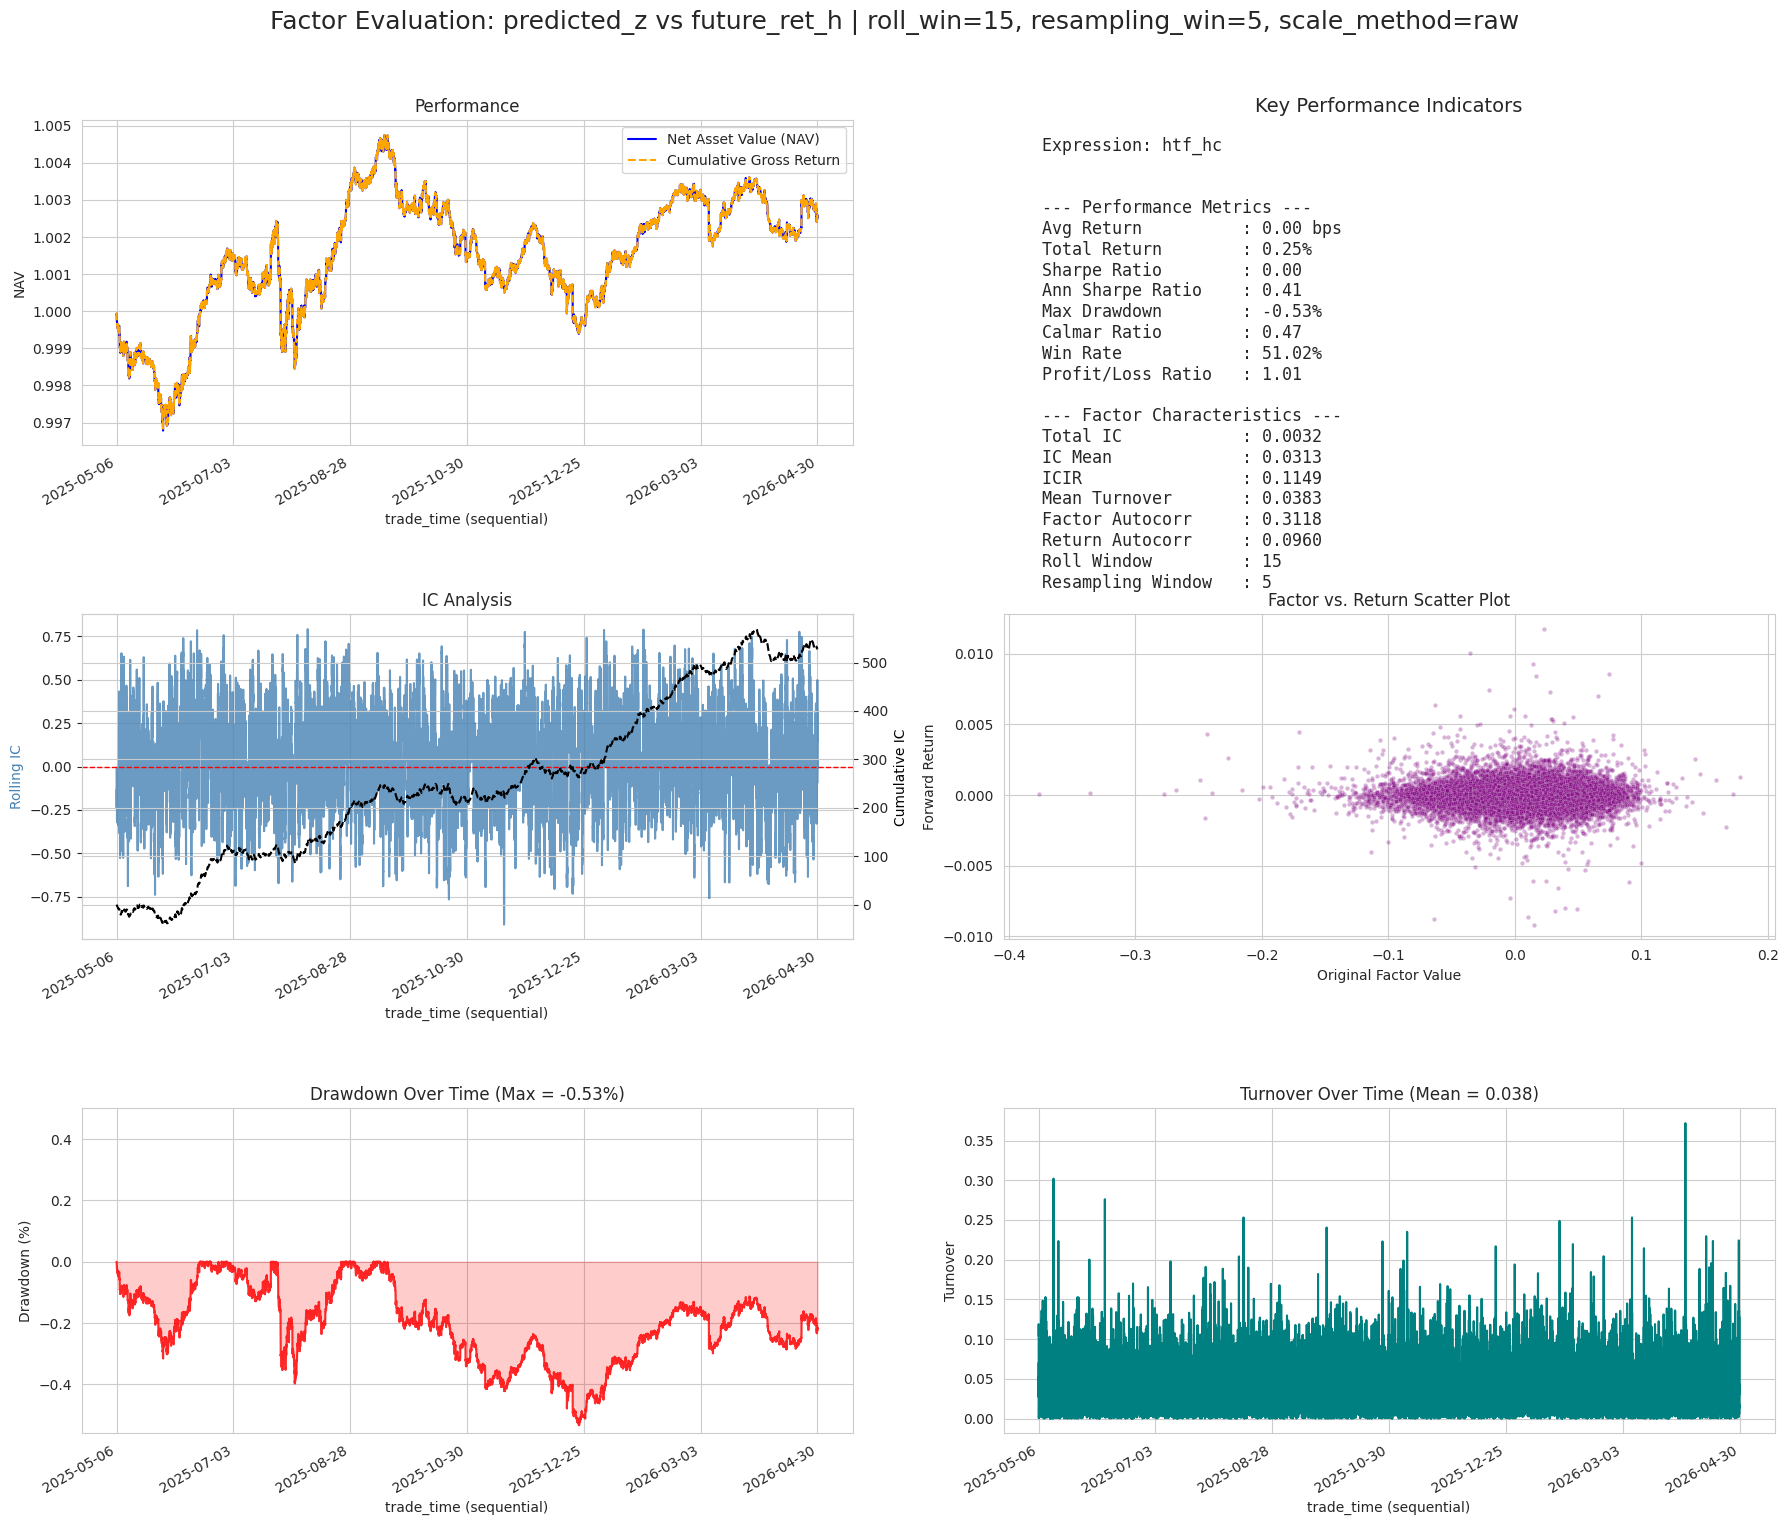

In [25]:
evaluate1_htf_hc = FactorEvaluate1(factor_data=results_htf1_HC,
                                factor_name='predicted_z',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='htf_hc',
                                resampling_win=5)
evaluate1_htf_hc.run()
evaluate1_htf_hc.plot_results()

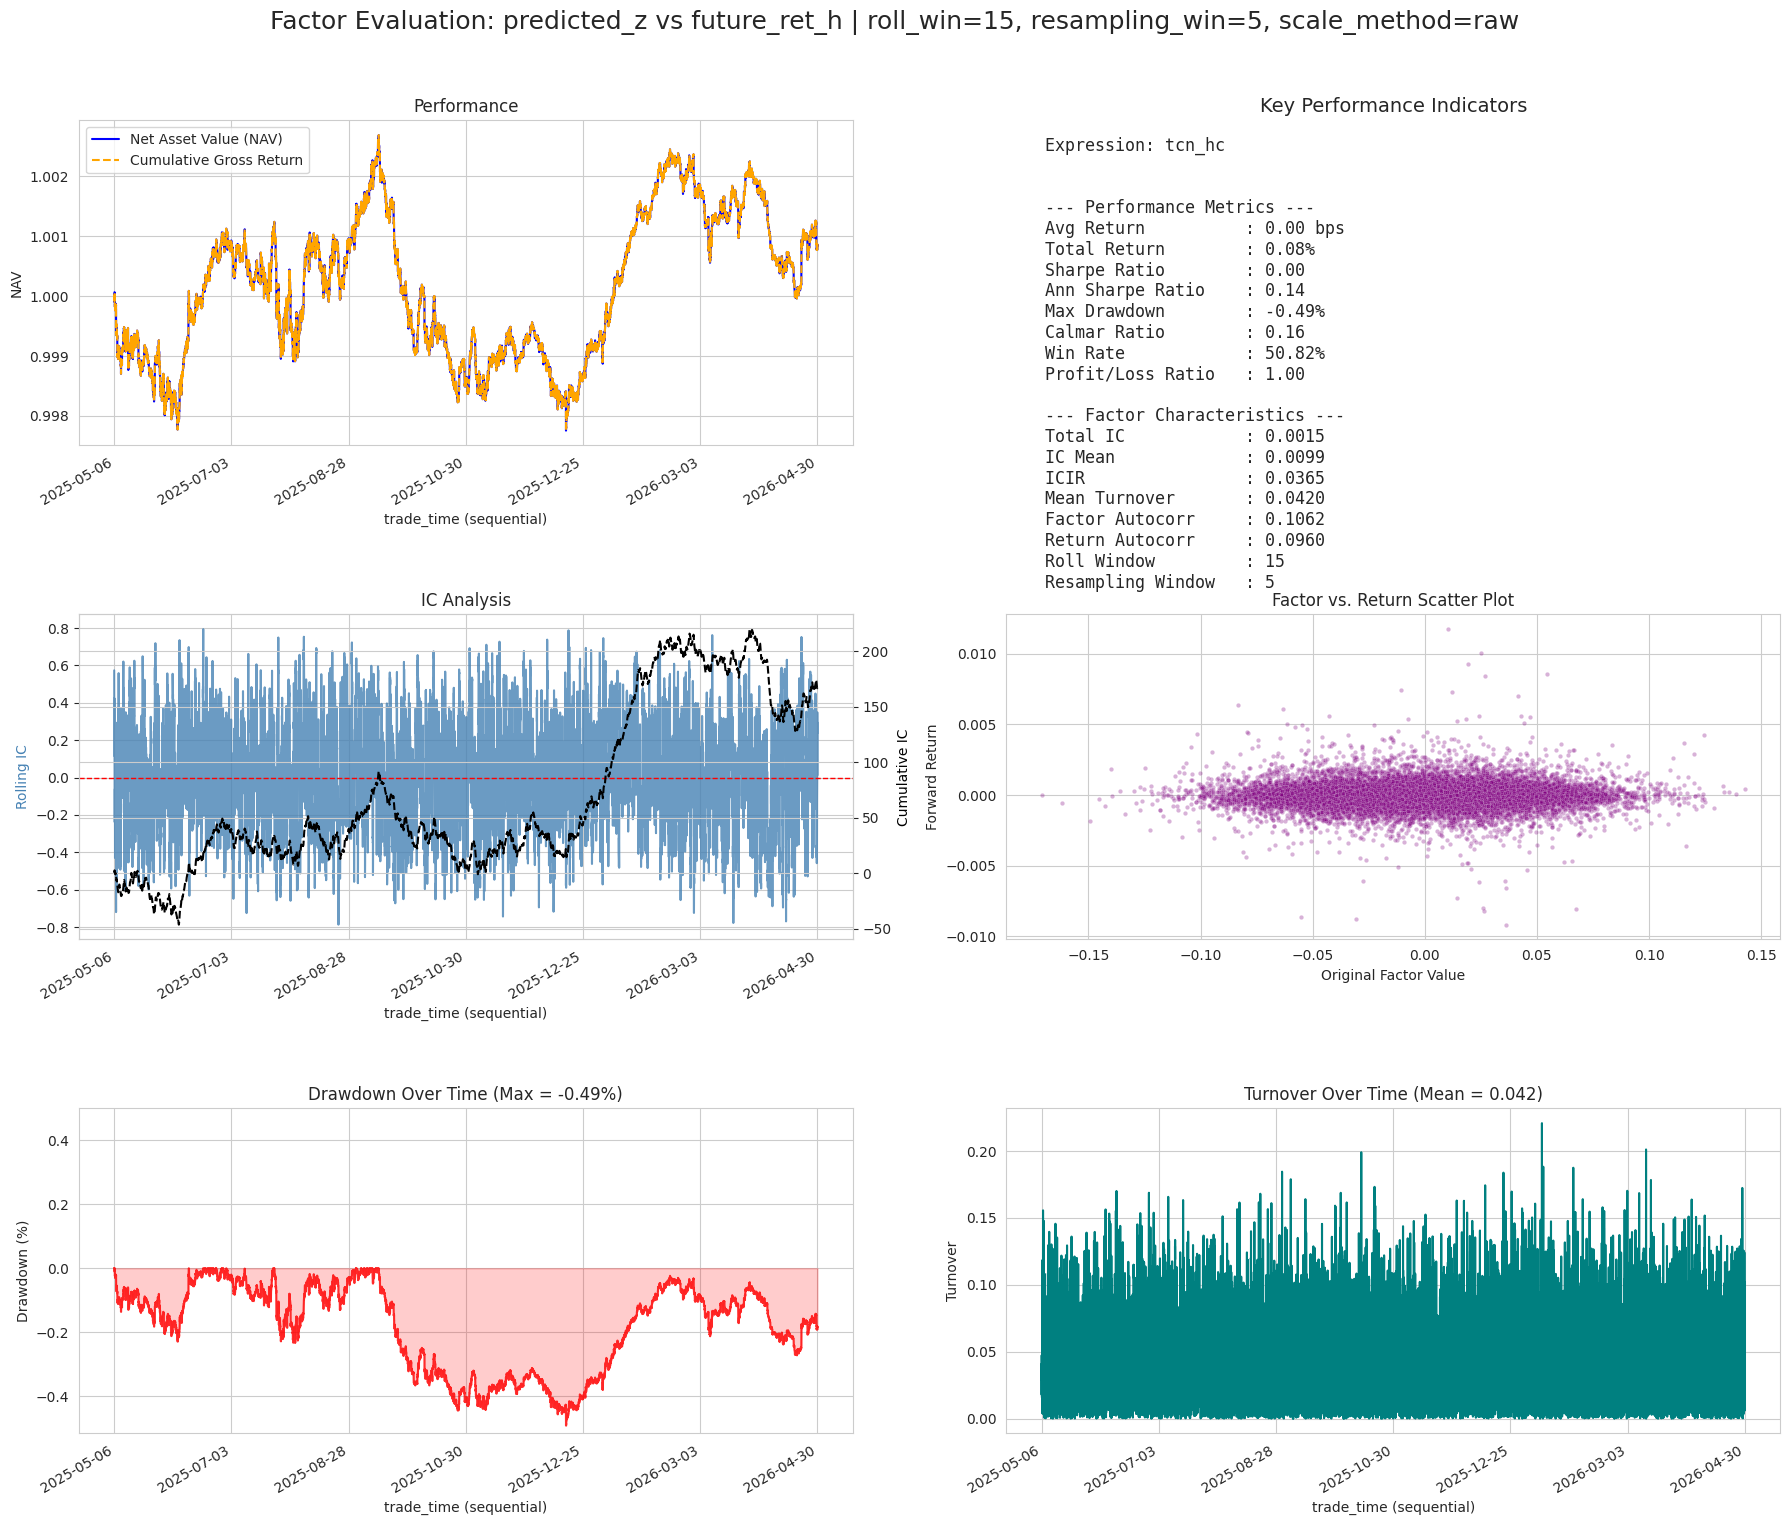

In [26]:
evaluate1_tcn_hc = FactorEvaluate1(factor_data=results_tcn1_HC,
                                factor_name='predicted_z',
                                ret_name='future_ret_h',
                                roll_win=15,
                                fee=0.0,
                                scale_method='raw',
                                expression='tcn_hc',
                                resampling_win=5)
evaluate1_tcn_hc.run()
evaluate1_tcn_hc.plot_results()